In [7]:
import pandas as pd
import glob
import os

# 1. Load all cleaned files
files = glob.glob('../data/*_clean.csv')
all_countries = []

for file in files:
    # Get the country name from the filename (e.g., 'ethiopia' from 'ethiopia_clean.csv')
    country_name = os.path.basename(file).split('_')[0].capitalize()
    
    df = pd.read_csv(file)
    
    # 2. Add the Country column so we can compare them later
    df['Country'] = country_name
    
    # 3. Ensure the date column is treated as a datetime object
    # (Note: Check if your cleaned CSV saved it as 'Date' or 'DATE')
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
    elif 'DATE' in df.columns:
        df['DATE'] = pd.to_datetime(df['DATE'])
        df.set_index('DATE', inplace=True)
        
    all_countries.append(df)

# 4. Combine everything into one big DataFrame
comparison_df = pd.concat(all_countries)

# 5. Check the result
print(f"Total rows merged: {len(comparison_df)}")
print(f"Countries included: {comparison_df['Country'].unique()}")
comparison_df.head()

Total rows merged: 20500
Countries included: <ArrowStringArray>
['Ethiopia', 'Tanzania', 'Nigeria', 'Kenya', 'Sudan']
Length: 5, dtype: str


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,MONTH
2015-01-01 00:00:00,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,1.0
2015-01-02 00:00:00,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,1.0
2015-01-03 00:00:00,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1.0
2015-01-04 00:00:00,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1.0
2015-01-05 00:00:00,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1.0


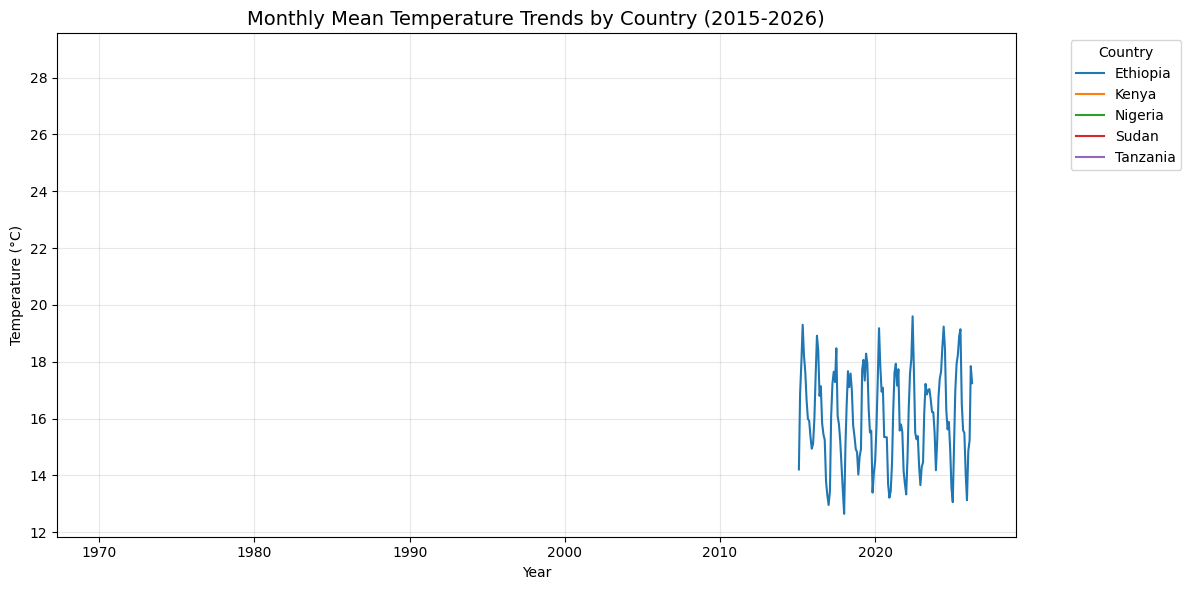

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
comparison_df.index = pd.to_datetime(comparison_df.index)
# Resample to Monthly average for all countries
pivot_temp = comparison_df.groupby(['Country', pd.Grouper(freq='ME')])['T2M'].mean().unstack(level=0)

plt.figure(figsize=(12, 6))
sns.lineplot(data=pivot_temp, dashes=False)
plt.title('Monthly Mean Temperature Trends by Country (2015-2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

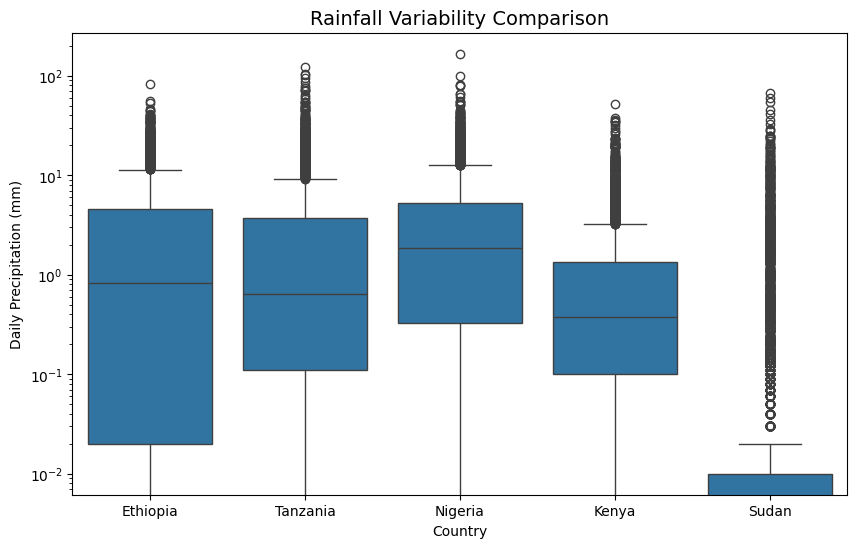

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='PRECTOTCORR', data=comparison_df)
plt.title('Rainfall Variability Comparison', fontsize=14)
plt.ylabel('Daily Precipitation (mm)')
plt.yscale('log') # Using log scale because rain data is often skewed
plt.show()

In [10]:
# Calculate key metrics per country
vulnerability_table = comparison_df.groupby('Country').agg({
    'T2M': 'mean',
    'T2M_MAX': 'max',
    'PRECTOTCORR': 'std', # Higher Standard Deviation = Higher risk/variability
}).rename(columns={
    'T2M': 'Avg_Temp',
    'T2M_MAX': 'Max_Recorded_Heat',
    'PRECTOTCORR': 'Rain_Variability'
})

# Add a count for Extreme Heat Days (>35°C)
vulnerability_table['Extreme_Heat_Days'] = comparison_df[comparison_df['T2M_MAX'] > 35].groupby('Country').size()
vulnerability_table.fillna(0, inplace=True) # If a country had 0 days above 35

print(vulnerability_table.sort_values(by='Extreme_Heat_Days', ascending=False))

           Avg_Temp  Max_Recorded_Heat  Rain_Variability  Extreme_Heat_Days
Country                                                                    
Sudan     28.754319              45.96          3.061236             2686.0
Ethiopia  16.068500              30.93          6.289061                0.0
Kenya     20.430117              34.27          3.181273                0.0
Nigeria   26.651689              32.88          7.274582                0.0
Tanzania  26.800900              33.93          7.957105                0.0
